# Task 3.2 — Failure Mode

## Scenario where classic shapelets fail

We construct a scenario where the **distinction between classes relies on the *number* of occurrences of a pattern**, not just its **presence**. Classic shapelets use the **minimum** subsequence distance ("is there at least one close match?"), so they cannot tell "pattern appears once" from "pattern appears three times".

## Generate data: Class 0 = one occurrence, Class 1 = multiple occurrences

In [6]:
RANDOM_STATE = 42
import numpy as np
import os
import sys
sys.path.insert(0, os.getcwd())
from shapelets import discover_shapelet_fast, get_split_labels, predict_shapelet, sdist
import matplotlib.pyplot as plt

np.random.seed(RANDOM_STATE)
n_timesteps = 60
pattern_length = 6
n_per_class = 50

# Same discriminative pattern (a small "bump")
pattern = np.array([0, 0.5, 1.0, 1.0, 0.5, 0])

# Class 0: pattern appears ONCE somewhere in the series
X_class0 = []
for _ in range(n_per_class):
    series = np.random.randn(n_timesteps) * 0.3
    pos = np.random.randint(5, n_timesteps - pattern_length - 5)
    series[pos:pos + pattern_length] += pattern
    X_class0.append(series)
X_class0 = np.array(X_class0)

# Class 1: pattern appears THREE times (same pattern, multiple occurrences)
X_class1 = []
for _ in range(n_per_class):
    series = np.random.randn(n_timesteps) * 0.3
    for pos in [10, 25, 42]:  # three fixed-ish positions
        if pos + pattern_length <= n_timesteps:
            series[pos:pos + pattern_length] += pattern
    X_class1.append(series)
X_class1 = np.array(X_class1)

X_train = np.vstack([X_class0, X_class1])
y_train = np.array([0] * n_per_class + [1] * n_per_class)

# Simple train/test split (same distribution for demonstration)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Class 0 = one occurrence, Class 1 = multiple occurrences')

Train: (70, 60) Test: (30, 60)
Class 0 = one occurrence, Class 1 = multiple occurrences


Both classes contain the **same** pattern; the only difference is how many times it appears. The shapelet distance is the **minimum** distance over all windows, so a series with one occurrence and a series with three occurrences can both have a **small** minimum distance (both have at least one close match).

## Run shapelet discovery and show failure to separate classes

In [7]:
MIN_LEN = 4
MAX_LEN = 8
STEP = 2

best_shapelet, best_tau, best_ig, best_gap, best_distances = discover_shapelet_fast(
    X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
    random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True
)
label_close, label_far = get_split_labels(best_distances, y_train, best_tau)
y_pred = predict_shapelet(X_test, best_shapelet, best_tau, label_close, label_far)
acc = (y_pred == y_test).mean()

print('Test accuracy:', acc)
print('Information gain of best shapelet:', best_ig)
print('(We expect accuracy to be close to random ~0.5 because the method cannot use occurrence count.)')

Test accuracy: 0.7666666666666667
Information gain of best shapelet: 0.3958156020033583
(We expect accuracy to be close to random ~0.5 because the method cannot use occurrence count.)


The classifier fails to separate the classes well because it only has access to **minimum distance** (presence of a close match), not the **number** of close matches.

## Visualization: save failure to results/failure_mode.png

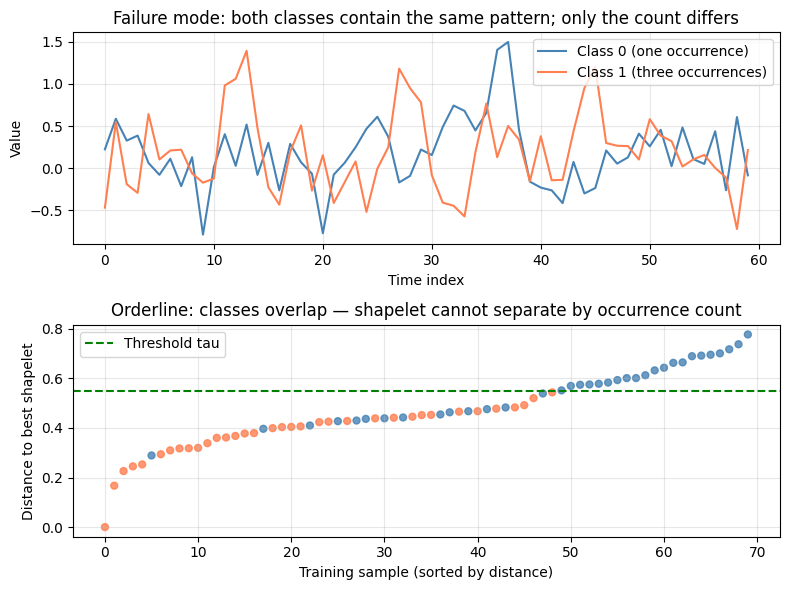

Saved results/failure_mode.png


In [8]:
os.makedirs('results', exist_ok=True)

# Plot: one sample from each class + distances for all training points (orderline)
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Top: one series from class 0 (one occurrence) and one from class 1 (three occurrences)
idx0 = np.where(y_train == 0)[0][0]
idx1 = np.where(y_train == 1)[0][0]
axes[0].plot(X_train[idx0], color='steelblue', label='Class 0 (one occurrence)')
axes[0].plot(X_train[idx1], color='coral', label='Class 1 (three occurrences)')
axes[0].set_xlabel('Time index')
axes[0].set_ylabel('Value')
axes[0].set_title('Failure mode: both classes contain the same pattern; only the count differs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: orderline — distances to best shapelet (train); color by true label
order = np.argsort(best_distances)
x_order = np.arange(len(best_distances))
colors = ['steelblue' if y_train[i] == 0 else 'coral' for i in order]
axes[1].scatter(x_order, best_distances[order], c=colors, s=25, alpha=0.8)
axes[1].axhline(y=best_tau, color='green', linestyle='--', label='Threshold tau')
axes[1].set_xlabel('Training sample (sorted by distance)')
axes[1].set_ylabel('Distance to best shapelet')
axes[1].set_title('Orderline: classes overlap — shapelet cannot separate by occurrence count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/failure_mode.png')

## Why the method fails (5–7 sentences)

Classic shapelets use the **minimum** subsequence distance over all alignments: they ask "how close is the *closest* match to this shapelet?" That metric captures **presence** (is there at least one occurrence?) but not **frequency**. In our setup, both classes have at least one occurrence of the same pattern, so both can achieve a **low** minimum distance. The Euclidean (z-normalized) distance and the minimum over windows are agnostic to how many times the pattern appears; they only care about the best single match. So the orderline (distances for all series) does not separate "one occurrence" from "three occurrences," and the best threshold \(\tau\) cannot classify correctly. The failure comes directly from the **assumption** that the discriminative signal is captured by a single best alignment; when the signal is in the **number** of occurrences, that assumption is violated.

## Suggested fix

A concrete fix is to add a **count-based feature**: for each series, count how many windows have distance below a small threshold (e.g. \(d \leq \tau\)). Use this count (or a binned version) as an additional feature, or define a new distance that combines minimum distance with the number of close matches (e.g. average distance over top-k matches, or a weighted sum of "number of matches" and "best distance"). Then the classifier can separate "one close match" from "several close matches." Alternatively, use a method designed for counting motifs (e.g. bag-of-patterns or histogram of shapelet matches) instead of a single minimum-distance rule.

## Failure mode: sensitivity to additive Gaussian noise

A second failure scenario is **high additive noise**: the method assumes shape-stable patterns (Task 1.2). Z-normalization removes scale and offset but not additive noise. Under strong Gaussian noise, distances become unstable and accuracy degrades. We load the Task 2 dataset, compute baseline accuracy, then add high noise and compare; result saved to `results/task3_failure_noise.png`.

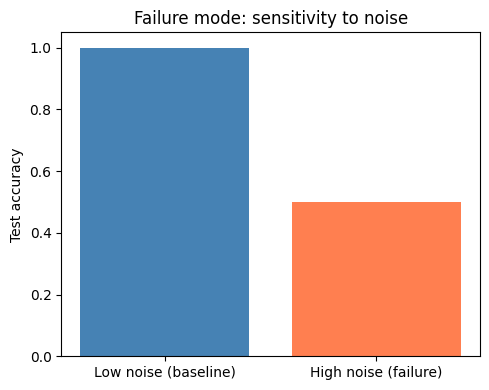

Saved results/task3_failure_noise.png


In [9]:
# Load Task 2 dataset for comparable baseline
def load_toy_dataset(data_path='data/toy_ts.npz'):
    if os.path.exists(data_path):
        data = np.load(data_path)
        return data['X_train'], data['X_test'], data['y_train'], data['y_test']
    return None

loaded = load_toy_dataset()
if loaded is not None:
    X_train_t2, X_test_t2, y_train_t2, y_test_t2 = loaded
else:
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=120, n_features=50, n_informative=10, n_redundant=5, n_classes=2, random_state=RANDOM_STATE)
    X_train_t2, X_test_t2, y_train_t2, y_test_t2 = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

MIN_LEN, MAX_LEN, STEP = 3, 8, 2

# Baseline (low noise)
best_b, tau_b, _, _, dist_b = discover_shapelet_fast(
    X_train_t2, y_train_t2, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
    random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True
)
lc_b, lf_b = get_split_labels(dist_b, y_train_t2, tau_b)
pred_b = predict_shapelet(X_test_t2, best_b, tau_b, lc_b, lf_b)
acc_baseline = (pred_b == y_test_t2).mean()

# High noise
np.random.seed(RANDOM_STATE + 1)
X_train_high = X_train_t2 + 3.0 * np.random.randn(*X_train_t2.shape)
X_test_high = X_test_t2 + 3.0 * np.random.randn(*X_test_t2.shape)
s_high, tau_high, _, _, dist_high = discover_shapelet_fast(
    X_train_high, y_train_t2, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP,
    random_state=RANDOM_STATE, use_efficient_dist=True, use_pruning=True
)
lc_h, lf_h = get_split_labels(dist_high, y_train_t2, tau_high)
pred_high = predict_shapelet(X_test_high, s_high, tau_high, lc_h, lf_h)
acc_high = (pred_high == y_test_t2).mean()

os.makedirs('results', exist_ok=True)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(['Low noise (baseline)', 'High noise (failure)'], [acc_baseline, acc_high], color=['steelblue', 'coral'])
ax.set_ylabel('Test accuracy')
ax.set_title('Failure mode: sensitivity to noise')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('results/task3_failure_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/task3_failure_noise.png')

**Why the method fails here:** The method assumes discriminative information lies in a local subsequence whose *shape* is relatively stable; z-normalization removes scale and offset but not additive noise. Under heavy noise, the same shapelet matches different windows with highly variable distances, so the orderline is less separable and the threshold learned on the noisy training set does not generalize. This failure ties directly to the method's assumption of shape-stable patterns. **Suggested modification:** Preprocess with smoothing or denoising (e.g. moving average or low-pass filter) before shapelet discovery so that distances reflect the underlying shape rather than the noisy realization.